In [8]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv(r"C:\Users\Saumya S\3-Uber_Data_New.csv")

# Convert datetime
df["pickup_dt"] = pd.to_datetime(
    df["pickup_dt"],
    dayfirst=True,
    format="mixed"
)

# Create time-based features
df["hour"] = df["pickup_dt"].dt.hour
df["day"] = df["pickup_dt"].dt.day
df["month"] = df["pickup_dt"].dt.month
df["day_of_week"] = df["pickup_dt"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Clean holiday column
df["hday"] = df["hday"].replace("?", "N")
df["hday"] = df["hday"].map({"Y": 1, "N": 0})

print(df.isnull().sum())

pickup_dt         0
borough        3043
pickups           2
spd               0
vsb               0
temp            359
dewp              0
slp               0
pcp01             0
pcp06             0
pcp24             0
sd                0
hday              0
hour              0
day               0
month             0
day_of_week       0
is_weekend        0
dtype: int64


In [6]:
print(df.columns.tolist())

['pickup_dt', 'borough', 'pickups', 'spd', 'vsb', 'temp', 'dewp', 'slp', 'pcp01', 'pcp06', 'pcp24', 'sd', 'hday']


In [7]:
print(df.head())

       pickup_dt    borough  pickups  spd   vsb  temp  dewp     slp  pcp01  \
0  1/1/2015 1:00      Bronx    152.0  5.0  10.0  30.0   7.0  1023.5    0.0   
1  1/1/2015 1:00   Brooklyn   1519.0  5.0  10.0   NaN   7.0  1023.5    0.0   
2  1/1/2015 1:00        EWR      0.0  5.0  10.0  30.0   7.0  1023.5    0.0   
3  1/1/2015 1:00  Manhattan   5258.0  5.0  10.0  30.0   7.0  1023.5    0.0   
4  1/1/2015 1:00     Queens    405.0  5.0  10.0  30.0   7.0  1023.5    0.0   

   pcp06  pcp24   sd hday  
0    0.0    0.0  0.0    Y  
1    0.0    0.0  0.0    ?  
2    0.0    0.0  0.0    Y  
3    0.0    0.0  0.0    Y  
4    0.0    0.0  0.0    Y  


In [9]:
# Handle missing borough values
df["borough"] = df["borough"].fillna("Unknown")

# Remove rows where target variable (pickups) is missing
df = df.dropna(subset=["pickups"])

# Numerical columns
num_cols = [
    "spd", "vsb", "temp", "dewp",
    "slp", "pcp01", "pcp06", "pcp24", "sd"
]

# Fill missing numerical values with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Check remaining missing values
print(df.isnull().sum())

pickup_dt      0
borough        0
pickups        0
spd            0
vsb            0
temp           0
dewp           0
slp            0
pcp01          0
pcp06          0
pcp24          0
sd             0
hday           0
hour           0
day            0
month          0
day_of_week    0
is_weekend     0
dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

# Select features
features = [
    "borough",
    "spd",
    "vsb",
    "temp",
    "dewp",
    "slp",
    "pcp01",
    "pcp06",
    "pcp24",
    "sd",
    "hday",
    "hour",
    "day",
    "month",
    "day_of_week",
    "is_weekend"
]

X = df[features]
y = df["pickups"]

# Convert categorical borough into numeric columns
X = pd.get_dummies(X, columns=["borough"], drop_first=True)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (29099, 21)
Target: (29099,)


In [11]:
# 80% training, 20% testing
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (23279, 21)
X_test : (5820, 21)
y_train: (23279,)
y_test : (5820,)


In [12]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Model Performance
-----------------
MAE : 88.65
RMSE: 265.53
R²  : 0.9431


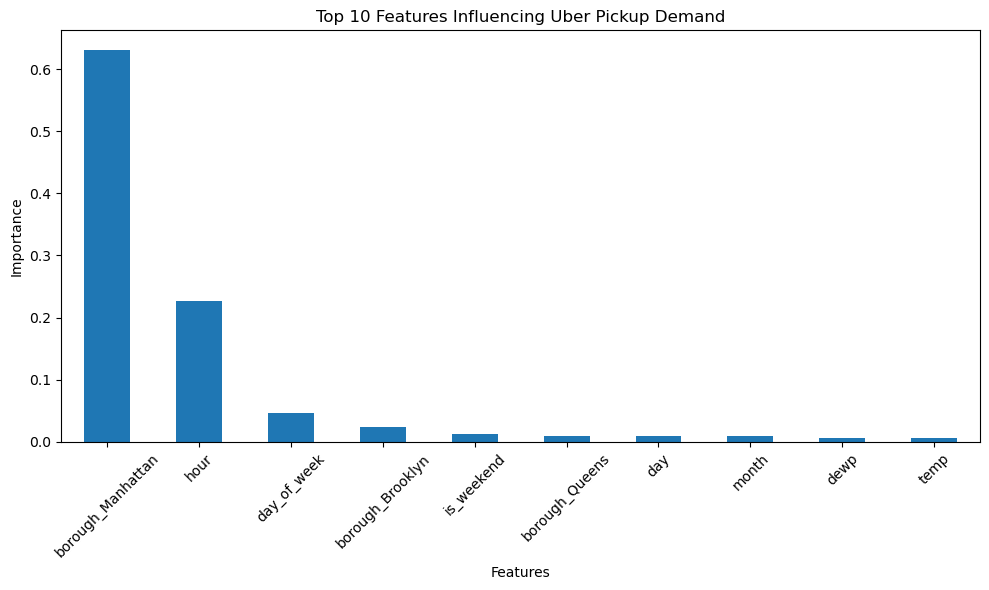

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Features Influencing Uber Pickup Demand")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

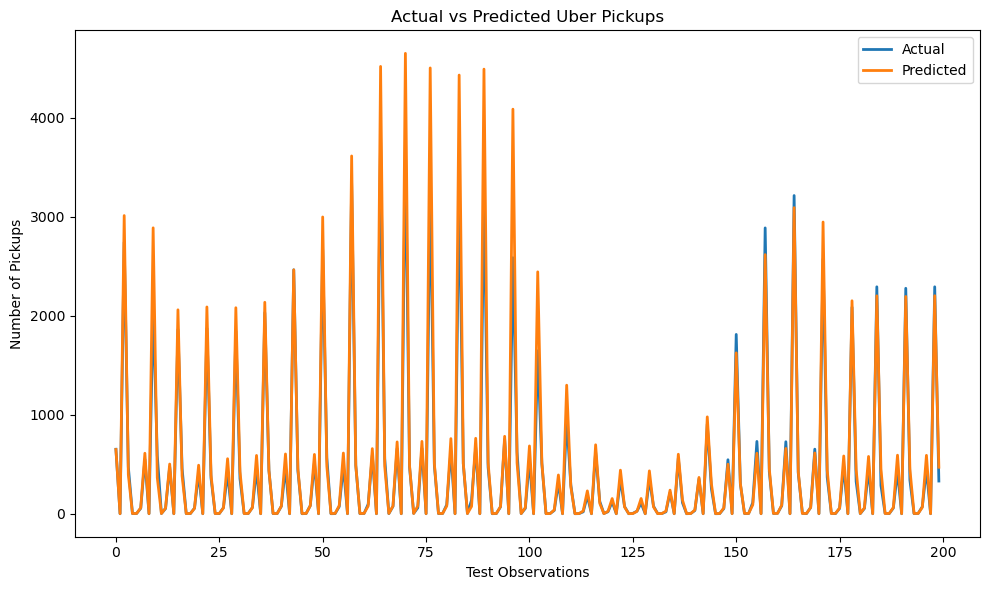

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    y_test.values[:200],
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred[:200],
    label="Predicted",
    linewidth=2
)

plt.title("Actual vs Predicted Uber Pickups")
plt.xlabel("Test Observations")
plt.ylabel("Number of Pickups")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Compare actual and predicted values
results = pd.DataFrame({
    "Actual Pickups": y_test.values,
    "Predicted Pickups": y_pred
})

results["Absolute Error"] = abs(
    results["Actual Pickups"] - results["Predicted Pickups"]
)

print(results.head(10))

   Actual Pickups  Predicted Pickups  Absolute Error
0           651.0             648.61            2.39
1             0.0               0.10            0.10
2          2742.0            3011.70          269.70
3           471.0             395.35           75.65
4             1.0               1.76            0.76
5             2.0               2.59            0.59
6            55.0              59.63            4.63
7           548.0             610.65           62.65
8             0.0               0.01            0.01
9          2098.0            2887.72          789.72


In [17]:
import joblib

# Save trained model
joblib.dump(rf_model, "uber_random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Conclusion

A Random Forest Regressor was developed to predict hourly Uber pickup demand using temporal, location, traffic, and weather-related features.

The model achieved an R² score of 0.9431 on the test dataset, with an MAE of 88.65 pickups and RMSE of 265.53 pickups.

Feature importance analysis showed that borough and time-related variables, particularly Manhattan and pickup hour, were among the strongest predictors of Uber pickup demand.

The model demonstrates how historical demand patterns and contextual factors can be used to estimate Uber pickup demand.